In [2]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dataset import FreiHand
from utils import mano

In [27]:
dataset_train = FreiHand(mode="train")
dataset_test = FreiHand(mode="test")


IndexError: index 4 is out of bounds for axis 0 with size 4

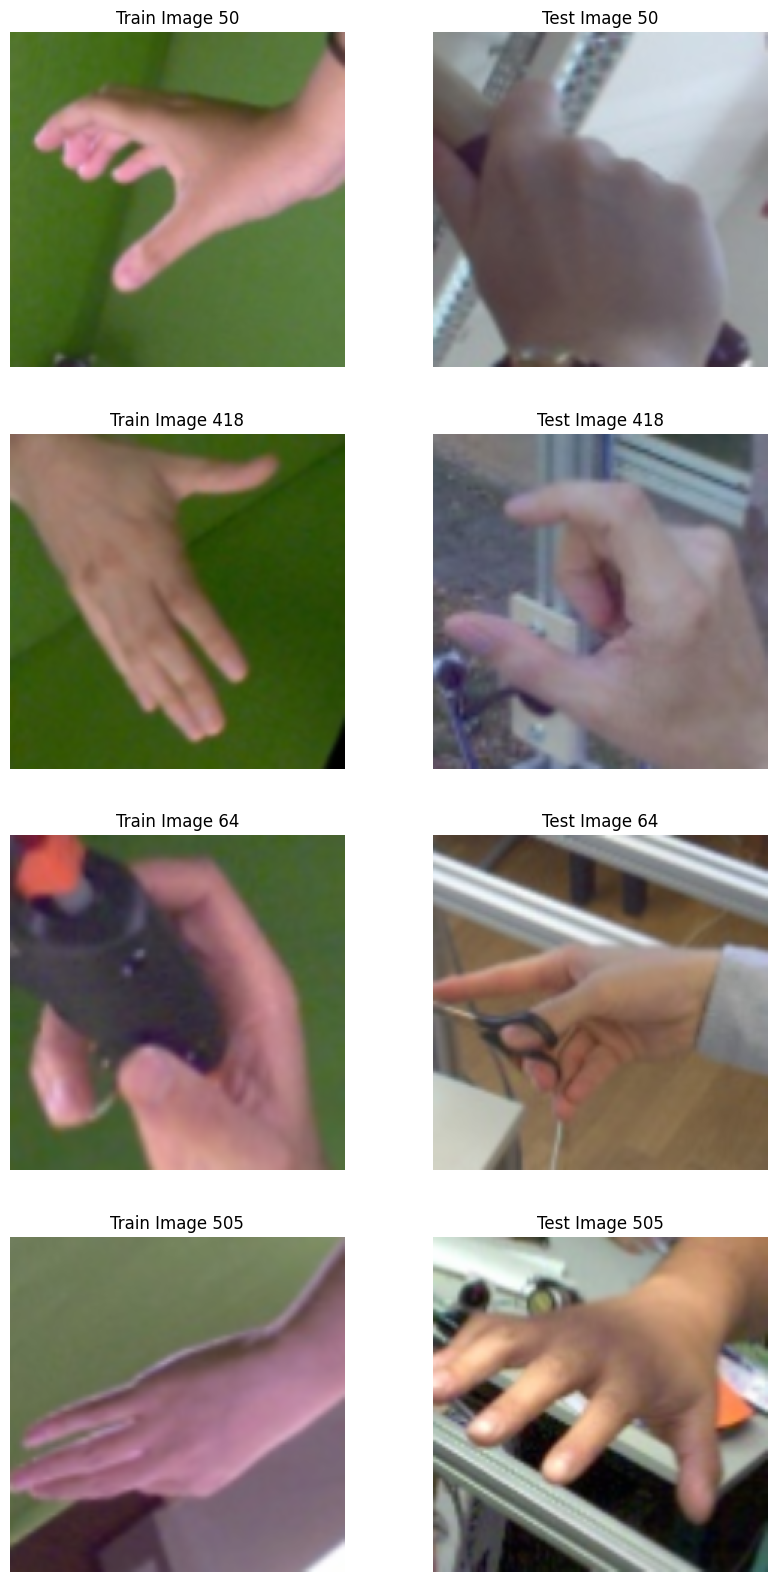

In [38]:
%matplotlib inline

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

# bx = 69

# train_sample = dataset_train[bx]
# test_sample =   dataset_test[bx]

# plt.subplot(1,2,1)
# plt.imshow(unnormalize(train_sample['image']))
# plt.subplot(1,2,2)
# plt.imshow(unnormalize(test_sample['image']))
# plt.show()

import random

bx = [random.randint(0, 1000) for _ in range(8)]  # 示例索引

# 创建 4 行 2 列的子图
fig, axs = plt.subplots(4, 2, figsize=(10, 20))

for i, index in enumerate(bx):
    train_sample = dataset_train[index]
    test_sample = dataset_test[index]
    
    # 显示训练集图像
    axs[i, 0].imshow(unnormalize(train_sample['image']))
    axs[i, 0].set_title(f'Train Image {index}')
    axs[i, 0].axis('off')  # 关闭坐标轴

    # 显示测试集图像
    axs[i, 1].imshow(unnormalize(test_sample['image']))
    axs[i, 1].set_title(f'Test Image {index}')
    axs[i, 1].axis('off')  # 关闭坐标轴

plt.tight_layout()  # 自动调整布局
plt.show()

In [3]:
dataset = FreiHand(background_removal=True, mode="test")
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4)

In [4]:
from tqdm import tqdm

data_iter = iter(dataloader)
for _ in tqdm(range(233), ncols=50):
    data_item = next(data_iter)

100%|███████████| 233/233 [00:04<00:00, 47.90it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179042..2.6170833].


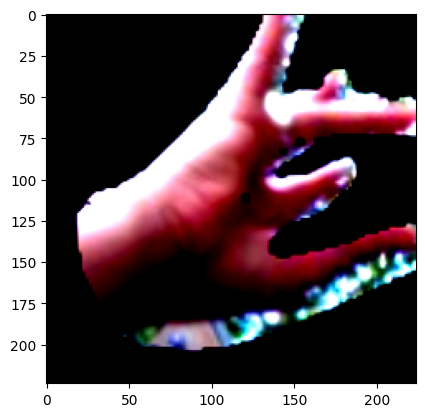

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

bx = 1

plt.clf()
image = data_item['image'][bx]
plt.imshow(image.permute(1,2,0))
plt.show()

In [6]:
pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))

In [7]:
import torch
import resnet

model: torch.nn.Module = resnet.pose_resnet50()
ckpt = torch.load("logs/23-20240929-1/checkpoint-599.pth", map_location="cpu", weights_only=False)
# logs/22-20240919-1/checkpoint-29.pth
model.load_state_dict(ckpt["model"])
model.to("cuda:5")
model.eval()
pass

trigger EVAL mode


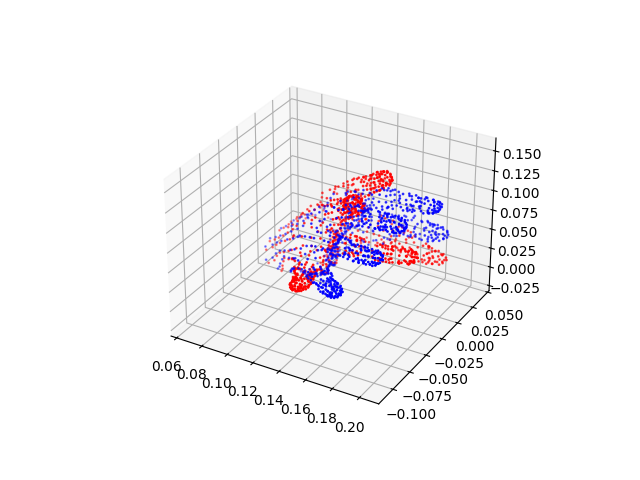

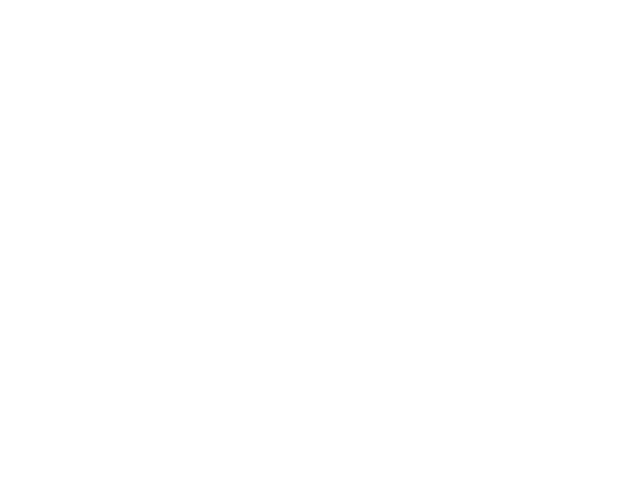

In [8]:
%matplotlib widget

with torch.no_grad():
    pose_pred = model(data_item["image"].to("cuda:5"))
    pose_pred = pose_pred[bx:bx+1].reshape(1,-1).to("cpu").detach()

pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))
output_pred = mano.layer["right"](betas=shape,
                                  hand_pose=pose_pred[:,3:],
                                  global_orient=pose_pred[:,:3],
                                  transl=torch.zeros(1,3))

mesh_gt = output_gt.vertices[0]
mesh_pred = output_pred.vertices[0]

plt.clf()
fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(mesh_gt[:,0],mesh_gt[:,1],mesh_gt[:,2], s=1, c='r')
ax3d.scatter(mesh_pred[:,0],mesh_pred[:,1],mesh_pred[:,2], s=1, c='b')

plt.show()